# 04 — Network Analysis
User reply network, centrality, community detection


In [2]:
# Shared Setup — run this first
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import seaborn as sns, warnings, re
from collections import Counter
from datetime import datetime
from tqdm import tqdm
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

POSTS_FILE    = "../data/posts_soccer.json"
COMMENTS_FILE = "../data/comments_soccer.json"

with open(POSTS_FILE, "r", encoding="utf-8") as f:
    posts_raw = json.load(f)
with open(COMMENTS_FILE, "r", encoding="utf-8") as f:
    comments_raw = json.load(f)

posts_df = pd.DataFrame([{
    "id": p.get("id"), "author": p.get("author"),
    "title": p.get("title",""), "selftext": p.get("selftext",""),
    "score": p.get("score",0), "upvote_ratio": p.get("upvote_ratio",0),
    "num_comments": p.get("num_comments",0), "subreddit": p.get("subreddit"),
    "flair": p.get("link_flair_text"), "created_utc": p.get("created_utc"),
} for p in posts_raw])

comments_df = pd.DataFrame([{
    "id": c.get("id"), "author": c.get("author"),
    "body": c.get("body",""), "score": c.get("score",0),
    "parent_id": c.get("parent_id"), "link_id": c.get("link_id"),
    "subreddit": c.get("subreddit"), "created_utc": c.get("created_utc"),
    "controversiality": c.get("controversiality",0),
} for c in comments_raw])

REMOVE = [None, "[deleted]", "AutoModerator", "BotDefense"]
posts_df["datetime"]    = pd.to_datetime(posts_df["created_utc"], unit="s")
comments_df["datetime"] = pd.to_datetime(comments_df["created_utc"], unit="s")
posts_df    = posts_df[~posts_df["author"].isin(REMOVE)].reset_index(drop=True)
comments_df = comments_df[~comments_df["author"].isin(REMOVE)].reset_index(drop=True)
posts_df["full_text"] = posts_df["title"] + " " + posts_df["selftext"].fillna("")

print(f"Posts: {len(posts_df):,} | Comments: {len(comments_df):,}")
print(f"Date range: {posts_df["datetime"].min().date()} to {posts_df["datetime"].max().date()}")


Posts: 18,088 | Comments: 4,651
Date range: 2022-10-31 to 2022-12-19


## 5. Network Construction
Build a directed weighted user-reply network from comment `parent_id` chains.

In [3]:
# ── BUILD USER REPLY NETWORK ───────────────────────────────────────────────
# Nodes = Reddit users
# Edges = user A replied to user B (directed)
# Weight = number of times A replied to B

print('Building comment-to-comment reply network...')

# Map comment id → author for fast lookup
id_to_author = dict(zip(comments_df['id'], comments_df['author']))

# Only keep comment→comment replies (parent starts with t1_)
comment_replies = comments_df[comments_df['parent_id'].str.startswith('t1_')].copy()
comment_replies['parent_comment_id'] = comment_replies['parent_id'].str[3:]

# Get parent author
comment_replies['parent_author'] = comment_replies['parent_comment_id'].map(id_to_author)

# Drop where parent author not found or same as commenter (self-reply)
edges_df = comment_replies.dropna(subset=['parent_author'])
edges_df = edges_df[edges_df['author'] != edges_df['parent_author']]
edges_df = edges_df[~edges_df['author'].isin(['[deleted]', None])]
edges_df = edges_df[~edges_df['parent_author'].isin(['[deleted]', None])]

# Count edge weights
edge_weights = (edges_df
    .groupby(['author', 'parent_author'])
    .size()
    .reset_index(name='weight')
)

print(f'Total reply edges found: {len(edge_weights):,}')
print(f'Unique users involved:   {pd.concat([edge_weights["author"], edge_weights["parent_author"]]).nunique():,}')

Building comment-to-comment reply network...
Total reply edges found: 2,308
Unique users involved:   1,612


In [7]:
# ── BUILD NETWORKX GRAPH ───────────────────────────────────────────────────
import networkx as nx
G = nx.DiGraph()

for _, row in edge_weights.iterrows():
    G.add_edge(row['author'], row['parent_author'], weight=row['weight'])

print(f'Graph stats:')
print(f'  Nodes (users):  {G.number_of_nodes():,}')
print(f'  Edges (replies): {G.number_of_edges():,}')
print(f'  Is directed:    {nx.is_directed(G)}')

# For some analyses, work with largest weakly connected component
largest_wcc = max(nx.weakly_connected_components(G), key=len)
G_main = G.subgraph(largest_wcc).copy()
print(f'\nLargest connected component:')
print(f'  Nodes: {G_main.number_of_nodes():,}')
print(f'  Edges: {G_main.number_of_edges():,}')
print(f'  Density: {nx.density(G_main):.6f}')

Graph stats:
  Nodes (users):  1,612
  Edges (replies): 2,308
  Is directed:    True

Largest connected component:
  Nodes: 1,306
  Edges: 2,076
  Density: 0.001218


## 6. Network Analysis — Centrality & Influence

In [8]:
# ── CENTRALITY MEASURES ────────────────────────────────────────────────────
print('Computing centrality measures (this may take a minute)...')

# In-degree: how many unique users reply TO this user (being responded to = influential)
in_degree  = dict(G_main.in_degree(weight='weight'))

# Out-degree: how many users this user replies to (active participants)
out_degree = dict(G_main.out_degree(weight='weight'))

# PageRank: global influence score (like Google PageRank)
pagerank = nx.pagerank(G_main, weight='weight', alpha=0.85)

# Betweenness centrality: bridges between communities
# (expensive on large graphs — use approximate on sample)
if G_main.number_of_nodes() > 5000:
    print('  Using approximate betweenness (graph is large)...')
    betweenness = nx.betweenness_centrality(G_main, k=500, normalized=True, weight='weight')
else:
    betweenness = nx.betweenness_centrality(G_main, normalized=True, weight='weight')

# Build centrality dataframe
centrality_df = pd.DataFrame({
    'user':         list(pagerank.keys()),
    'pagerank':     list(pagerank.values()),
    'in_degree':    [in_degree.get(u, 0) for u in pagerank.keys()],
    'out_degree':   [out_degree.get(u, 0) for u in pagerank.keys()],
    'betweenness':  [betweenness.get(u, 0) for u in pagerank.keys()],
}).sort_values('pagerank', ascending=False)

print('\n=== TOP 15 MOST INFLUENTIAL USERS (by PageRank) ===')
print(centrality_df.head(15).to_string(index=False))

Computing centrality measures (this may take a minute)...

=== TOP 15 MOST INFLUENTIAL USERS (by PageRank) ===
              user  pagerank  in_degree  out_degree  betweenness
       whysoujjwal  0.010235         17          10     0.050258
LeftLeftRightRight  0.008401          8           1     0.000410
  ThereWillBeGoals  0.008263         24          20     0.052279
         Insanel0l  0.007966         16           7     0.005794
     GreatSpaniard  0.007805         15           6     0.009910
      justforkikkk  0.007280          1           1     0.000000
   Zilllnaijaboy99  0.007171         20           3     0.006211
             msf97  0.006907         13           8     0.011469
             MCII7  0.006533         14           4     0.019053
    HeilWerneckLuk  0.006132         28          24     0.008866
         Polskidro  0.005670         19          23     0.030112
     trollatron786  0.005442          6           1     0.000413
 Dependent-Ad-7608  0.005381         20     

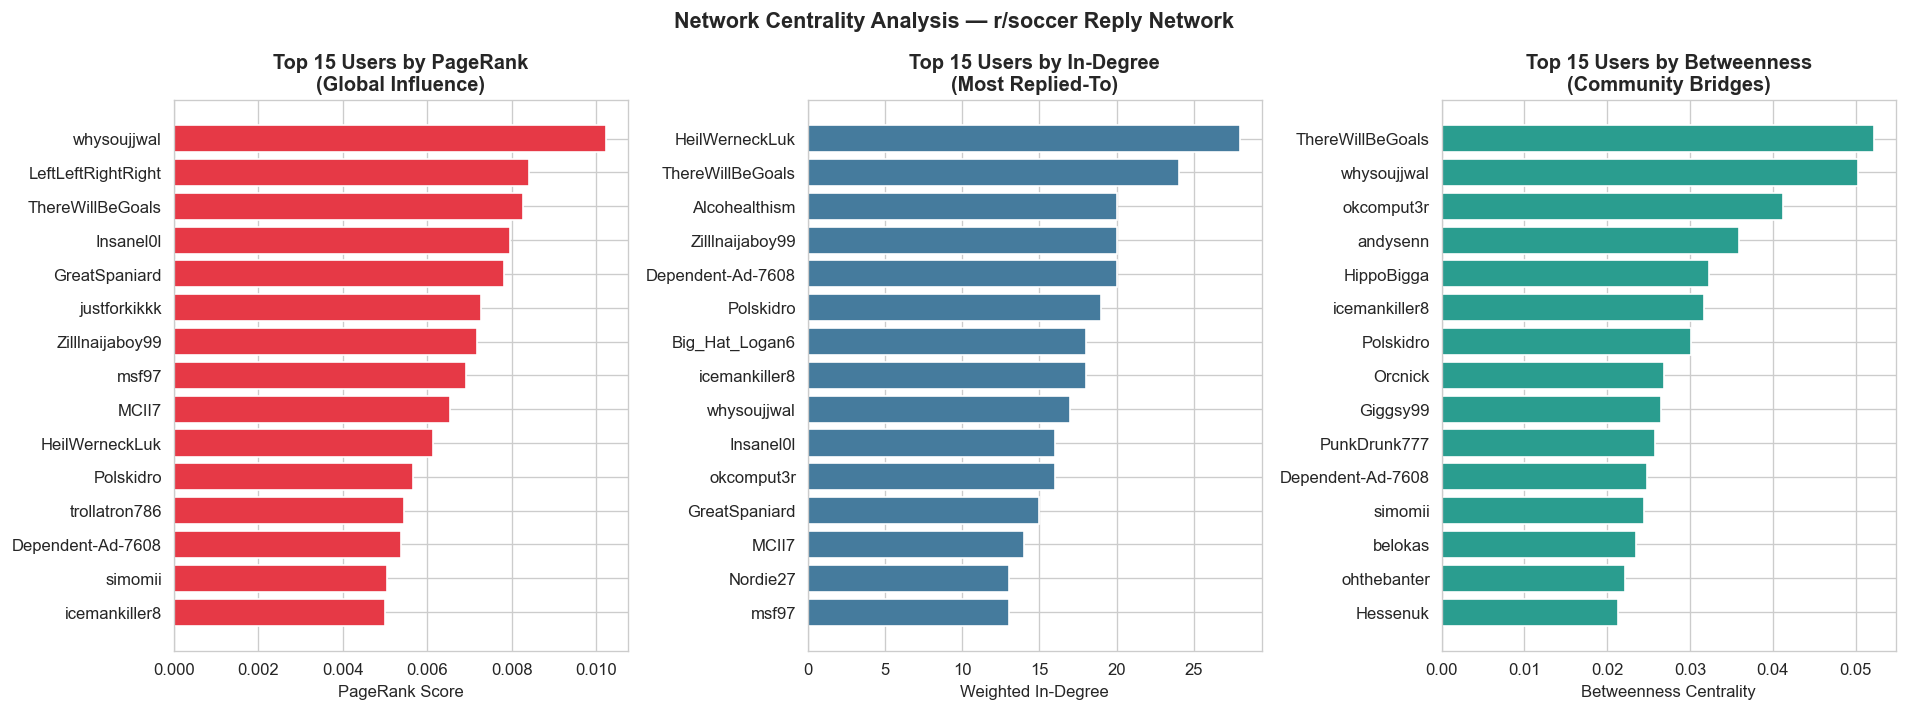

Saved: centrality_analysis.png


In [9]:
# ── CENTRALITY VISUALISATIONS ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Top 15 by PageRank
top_pr = centrality_df.head(15).sort_values('pagerank')
axes[0].barh(top_pr['user'], top_pr['pagerank'], color='#e63946')
axes[0].set_title('Top 15 Users by PageRank\n(Global Influence)', fontweight='bold')
axes[0].set_xlabel('PageRank Score')

# Top 15 by In-Degree (most replied-to)
top_in = centrality_df.nlargest(15, 'in_degree').sort_values('in_degree')
axes[1].barh(top_in['user'], top_in['in_degree'], color='#457b9d')
axes[1].set_title('Top 15 Users by In-Degree\n(Most Replied-To)', fontweight='bold')
axes[1].set_xlabel('Weighted In-Degree')

# Top 15 by Betweenness
top_bw = centrality_df.nlargest(15, 'betweenness').sort_values('betweenness')
axes[2].barh(top_bw['user'], top_bw['betweenness'], color='#2a9d8f')
axes[2].set_title('Top 15 Users by Betweenness\n(Community Bridges)', fontweight='bold')
axes[2].set_xlabel('Betweenness Centrality')

plt.suptitle('Network Centrality Analysis — r/soccer Reply Network', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('centrality_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: centrality_analysis.png')

In [11]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

comments_df['vader_compound'] = comments_df['body'].astype(str).apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

print(comments_df[['body', 'vader_compound']].head())

                                                body  vader_compound
0  He did the commentary for the New York Yankees...          0.6369
1                                      calthedragon?          0.0000
2                                        guy who won          0.5719
3                                           😂 drivel          0.4404
4  They can't handle pressure. Right now they're ...          0.6760


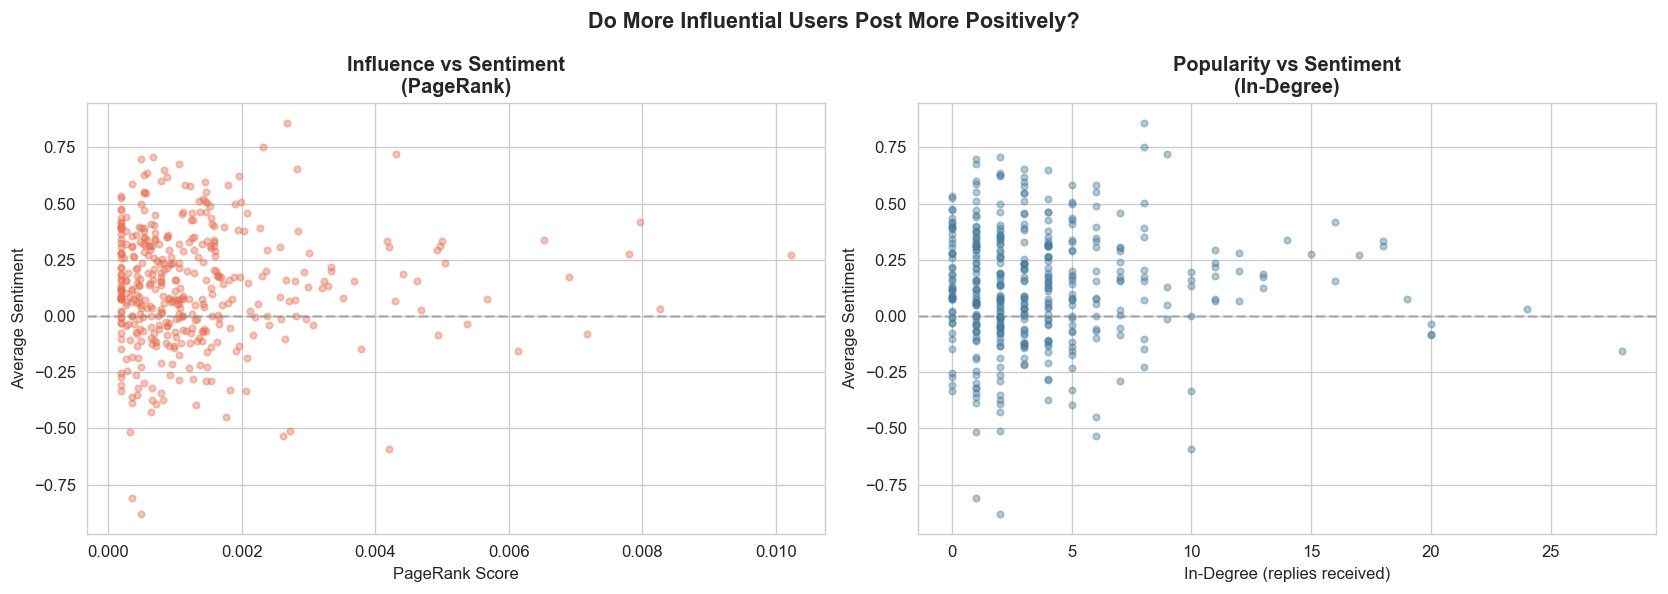

In [12]:
# ── CENTRALITY vs SENTIMENT ────────────────────────────────────────────────
# Do more influential users post more positively or negatively?
user_sentiment = (comments_df
    .groupby('author')['vader_compound']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_sentiment', 'count': 'num_comments', 'author': 'user'})
)

centrality_sentiment = centrality_df.merge(user_sentiment, on='user', how='inner')
centrality_sentiment = centrality_sentiment[centrality_sentiment['num_comments'] >= 3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(centrality_sentiment['pagerank'],
                centrality_sentiment['avg_sentiment'],
                alpha=0.4, color='#e76f51', s=15)
axes[0].set_xlabel('PageRank Score')
axes[0].set_ylabel('Average Sentiment')
axes[0].set_title('Influence vs Sentiment\n(PageRank)', fontweight='bold')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)

axes[1].scatter(centrality_sentiment['in_degree'],
                centrality_sentiment['avg_sentiment'],
                alpha=0.4, color='#457b9d', s=15)
axes[1].set_xlabel('In-Degree (replies received)')
axes[1].set_ylabel('Average Sentiment')
axes[1].set_title('Popularity vs Sentiment\n(In-Degree)', fontweight='bold')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Do More Influential Users Post More Positively?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('influence_vs_sentiment.png', bbox_inches='tight')
plt.show()

## 7. Community Detection (Louvain)

In [14]:
import community as community_louvain

# Louvain works on undirected graph
G_undirected = G_main.to_undirected()

print('Running Louvain community detection...')
partition = community_louvain.best_partition(G_undirected, weight='weight', random_state=42)

num_communities = len(set(partition.values()))
modularity      = community_louvain.modularity(partition, G_undirected)

print(f'Communities detected: {num_communities}')
print(f'Modularity score:     {modularity:.4f}  (>0.3 = meaningful structure)')

# Community size distribution
community_sizes = Counter(partition.values())
print(f'\nTop 10 community sizes:')
for comm_id, size in community_sizes.most_common(10):
    print(f'  Community {comm_id}: {size:,} users')

Running Louvain community detection...
Communities detected: 28
Modularity score:     0.8181  (>0.3 = meaningful structure)

Top 10 community sizes:
  Community 4: 159 users
  Community 21: 89 users
  Community 18: 68 users
  Community 9: 61 users
  Community 20: 61 users
  Community 10: 57 users
  Community 15: 57 users
  Community 27: 54 users
  Community 0: 48 users
  Community 8: 47 users


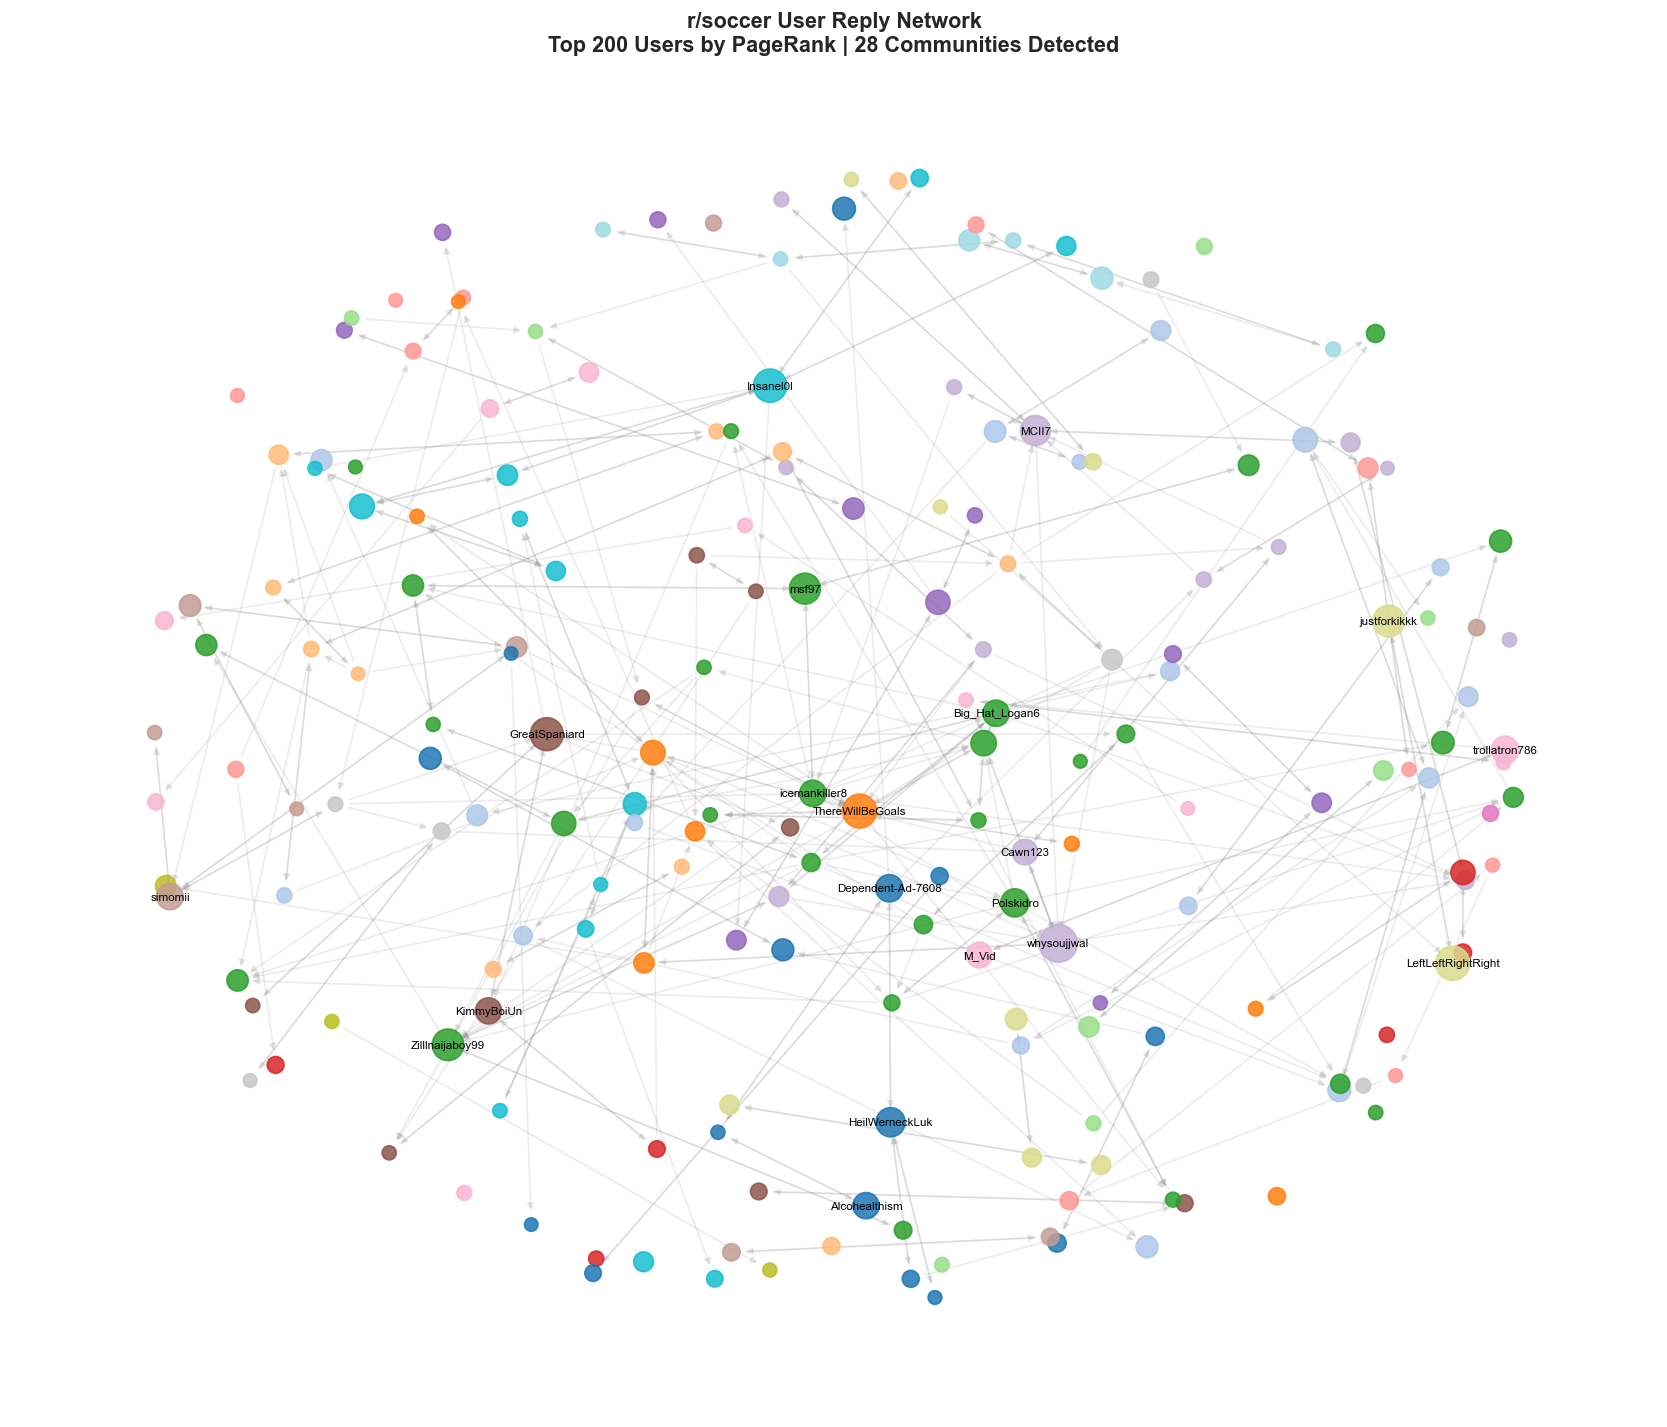

Saved: network_visualisation.png


In [15]:
# ── NETWORK VISUALISATION ──────────────────────────────────────────────────
# Visualise a manageable subgraph (top N nodes by PageRank)
TOP_N = 200
top_users = centrality_df.head(TOP_N)['user'].tolist()
G_viz = G_main.subgraph(top_users).copy()

# Assign community colors
comm_colors = plt.cm.tab20(np.linspace(0, 1, min(20, num_communities)))
node_colors = []
for node in G_viz.nodes():
    comm = partition.get(node, 0)
    node_colors.append(comm_colors[comm % 20])

node_sizes = [pagerank.get(n, 0) * 50000 for n in G_viz.nodes()]

fig, ax = plt.subplots(figsize=(14, 12))
pos = nx.spring_layout(G_viz, k=0.5, seed=42)

nx.draw_networkx_nodes(G_viz, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_viz, pos, alpha=0.15, arrows=True,
                       arrowsize=8, edge_color='gray', ax=ax)

# Label top 20 nodes
top20 = centrality_df.head(20)['user'].tolist()
labels = {n: n for n in G_viz.nodes() if n in top20}
nx.draw_networkx_labels(G_viz, pos, labels, font_size=7, ax=ax)

ax.set_title(f'r/soccer User Reply Network\nTop {TOP_N} Users by PageRank | {num_communities} Communities Detected',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('network_visualisation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: network_visualisation.png')

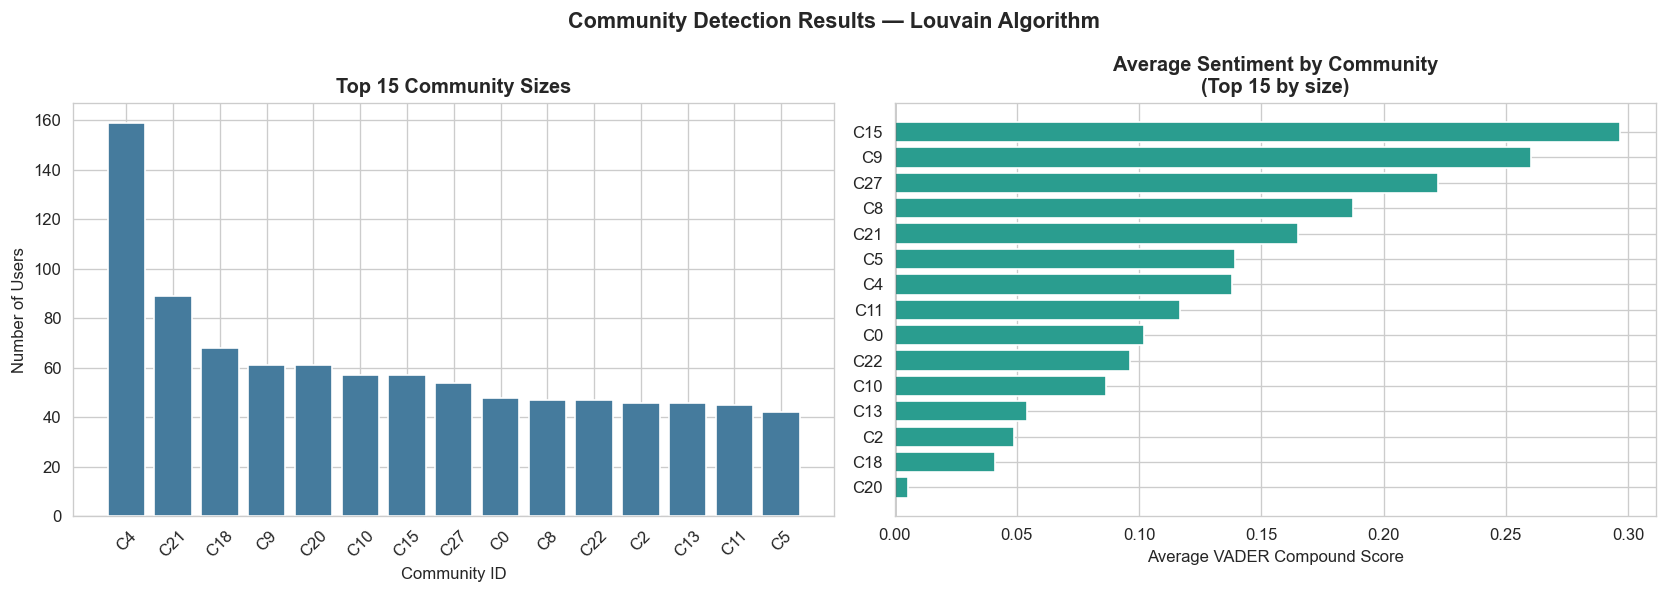

Saved: community_analysis.png


In [16]:
# ── COMMUNITY SIZE DISTRIBUTION ────────────────────────────────────────────
sizes = sorted(community_sizes.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of top communities
top_comms = community_sizes.most_common(15)
comm_ids  = [f'C{c}' for c, _ in top_comms]
comm_szs  = [s for _, s in top_comms]
axes[0].bar(comm_ids, comm_szs, color='#457b9d', edgecolor='white')
axes[0].set_title('Top 15 Community Sizes', fontweight='bold')
axes[0].set_xlabel('Community ID')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=45)

# Community sentiment comparison
node_comm_df = pd.DataFrame({'user': list(partition.keys()),
                              'community': list(partition.values())})
comm_sent = (node_comm_df
    .merge(user_sentiment, on='user', how='inner')
    .groupby('community')
    .agg(avg_sentiment=('avg_sentiment', 'mean'),
         size=('user', 'count'))
    .query('size >= 10')
    .nlargest(15, 'size')
    .sort_values('avg_sentiment')
)

bar_colors = ['#e63946' if s < 0 else '#2a9d8f' for s in comm_sent['avg_sentiment']]
axes[1].barh([f'C{i}' for i in comm_sent.index], comm_sent['avg_sentiment'], color=bar_colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Average Sentiment by Community\n(Top 15 by size)', fontweight='bold')
axes[1].set_xlabel('Average VADER Compound Score')

plt.suptitle('Community Detection Results — Louvain Algorithm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('community_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: community_analysis.png')

## 8. Summary & Key Insights

In [18]:
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    return 'Neutral'

comments_df['sentiment_label'] = comments_df['vader_compound'].apply(classify_sentiment)

print(comments_df[['vader_compound', 'sentiment_label']].head())

   vader_compound sentiment_label
0          0.6369        Positive
1          0.0000         Neutral
2          0.5719        Positive
3          0.4404        Positive
4          0.6760        Positive


In [25]:
# ── FINAL SUMMARY DASHBOARD ────────────────────────────────────────────────

print('=' * 60)
print('ANALYSIS SUMMARY — r/soccer World Cup 2022')
print('=' * 60)

# ---- SAFE TOPIC HANDLING ----
if 'topic_label' in posts_df.columns:
    num_topics = posts_df['topic_label'].nunique()
    top_topic_name = posts_df['topic_label'].value_counts().index[0]
    top_topic_count = posts_df['topic_label'].value_counts().iloc[0]
else:
    num_topics = 0
    top_topic_name = 'Not Available'
    top_topic_count = 0

# ---- SAFE SENTIMENT HANDLING ----
if 'sentiment_label' not in comments_df.columns:

    def classify_sentiment(score):
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        return 'Neutral'

    comments_df['sentiment_label'] = comments_df['vader_compound'].apply(classify_sentiment)

overall_sentiment = comments_df['vader_compound'].mean()
overall_label = 'Positive' if overall_sentiment > 0 else 'Negative'

print(f"""
DATASET
  Posts:               {len(posts_df):,}
  Comments:            {len(comments_df):,}
  Date range:          {posts_df['datetime'].min().date()} → {posts_df['datetime'].max().date()}
  Unique post authors: {posts_df['author'].nunique():,}
  Unique commenters:   {comments_df['author'].nunique():,}

SENTIMENT
  Overall tone:        {overall_sentiment:.4f} ({overall_label})

  Positive comments:   {(comments_df['sentiment_label'] == 'Positive').sum():,}
                        ({(comments_df['sentiment_label'] == 'Positive').mean() * 100:.1f}%)

  Neutral comments:    {(comments_df['sentiment_label'] == 'Neutral').sum():,}
                        ({(comments_df['sentiment_label'] == 'Neutral').mean() * 100:.1f}%)

  Negative comments:   {(comments_df['sentiment_label'] == 'Negative').sum():,}
                        ({(comments_df['sentiment_label'] == 'Negative').mean() * 100:.1f}%)

TOPIC MODELLING
  Topics discovered:   {num_topics}
  Top topic:           {top_topic_name} ({top_topic_count:,} posts)

NETWORK
  Total nodes:         {G.number_of_nodes():,} users
  Total edges:         {G.number_of_edges():,} reply interactions
  Main component:      {G_main.number_of_nodes():,} users
  Network density:     {nx.density(G_main):.6f}

COMMUNITY ANALYSIS
  Communities:         {num_communities}
  Modularity:          {modularity:.4f}

TOP INFLUENTIAL USER
  User:                {centrality_df.iloc[0]['user']}
  PageRank Score:      {centrality_df.iloc[0]['pagerank']:.5f}
""")

print('SAVED FIGURES:')

saved = [
    'activity_over_time.png',
    'eda_distributions.png',
    'sentiment_analysis.png',
    'sentiment_by_flair.png',
    'topic_modelling.png',
    'topic_distribution.png',
    'wordcloud.png',
    'centrality_analysis.png',
    'influence_vs_sentiment.png',
    'network_visualisation.png',
    'community_analysis.png',
]

for f in saved:
    print(f'  ✓ {f}')

ANALYSIS SUMMARY — r/soccer World Cup 2022

DATASET
  Posts:               18,088
  Comments:            4,651
  Date range:          2022-10-31 → 2022-12-19
  Unique post authors: 8,291
  Unique commenters:   2,292

SENTIMENT
  Overall tone:        0.1195 (Positive)

  Positive comments:   2,222
                        (47.8%)

  Neutral comments:    1,126
                        (24.2%)

  Negative comments:   1,303
                        (28.0%)

TOPIC MODELLING
  Topics discovered:   0
  Top topic:           Not Available (0 posts)

NETWORK
  Total nodes:         1,612 users
  Total edges:         2,308 reply interactions
  Main component:      1,306 users
  Network density:     0.001218

COMMUNITY ANALYSIS
  Communities:         28
  Modularity:          0.8181

TOP INFLUENTIAL USER
  User:                whysoujjwal
  PageRank Score:      0.01023

SAVED FIGURES:
  ✓ activity_over_time.png
  ✓ eda_distributions.png
  ✓ sentiment_analysis.png
  ✓ sentiment_by_flair.png
  ✓ topic_m